In [23]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
def sigmoid(z):
    return 1/(1+np.exp(-z))
def sigmoid_derivative(a):
    return  a*(1-a)




In [25]:
x=np.array([[1],[2],[3],[4],[5]])
y=np.array([[2],[4],[6],[8],[10]])

In [26]:
np.random.seed(1)
w1=np.random.randn(1,3)*0.1
b1=np.zeros((1,3))
w2=np.random.randn(3,1)*0.1
b2=np.zeros((1,1))

In [27]:
learning_rate = 0.5
epochs = 10
loss_list = []

In [28]:
for epoch in range(epochs):
    z1=np.dot(x,w1)+b1
    a1=sigmoid(z1)
    z2=np.dot(a1,w2)+b2
    y_pred=sigmoid(z2)

    loss=np.mean((y-y_pred)**2)
    loss_list.append(loss)

    
    error_output=(y_pred-y)
    d_output=error_output*sigmoid_derivative((y_pred))

    error_hidden=np.dot(d_output,w2.T)
    d_hidden = error_hidden * sigmoid_derivative(a1)

    w2 -= learning_rate * np.dot(a1.T, d_output)

    b2 -= learning_rate * np.sum(d_output, axis=0, keepdims=True)

    w1 -= learning_rate * np.dot(x.T, d_hidden)
    b1 -= learning_rate * np.sum(d_hidden, axis=0, keepdims=True)
    
    

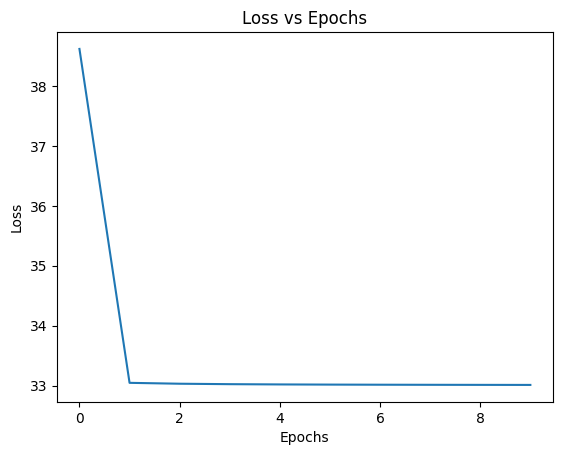

In [29]:
plt.plot(loss_list)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.show()

In [30]:
test_input = np.array([[6]]) / x.max()
z1_test = np.dot(test_input, w1) + b1
a1_test = sigmoid(z1_test)

z2_test = np.dot(a1_test, w2) + b2
prediction = sigmoid(z2_test)